Starting pipeline...
Loading from file: spotify_dataset.csv
Loaded shape: (267807, 4)
Bad rows dropped during load: 199
Columns: ['user_id', 'artistname', 'trackname', 'playlistname']
Removed empty/broken rows: 348
Removed duplicate (playlist, song) rows: 1,100
Shape after cleaning: (266359, 8)
Shape after frequency/size filtering: (4524, 13)
Unique playlists after filtering: 433
Unique songs after filtering: 401
Unique users after filtering: 171
Using all filtered playlists for modeling.

Playlist-level feature preview:


,playlist_key,user_id,playlist_name,n_songs,n_artists,avg_song_popularity,artist_diversity_ratio
0,02e7e8b832c68c0e38e6af926a225421 :: rock alter...,02e7e8b832c68c0e38e6af926a225421,Rock Alternativo,10,8,36.000000,0.800000
1,02e7e8b832c68c0e38e6af926a225421 :: starred,02e7e8b832c68c0e38e6af926a225421,Starred,17,17,38.764706,1.000000
2,031d69a7c94fdedb5e8648916af3a4e4 ::,031d69a7c94fdedb5e8648916af3a4e4,...,7,6,27.571429,0.857143
3,031d69a7c94fdedb5e8648916af3a4e4 :: foolies rh...,031d69a7c94fdedb5e8648916af3a4e4,foolies rhymin',7,5,27.428571,0.714286
4,031d69a7c94fdedb5e8648916af3a4e4 :: good stuffs,031d69a7c94fdedb5e8648916af3a4e4,Good stuffs.,7,6,28.571429,0.857143


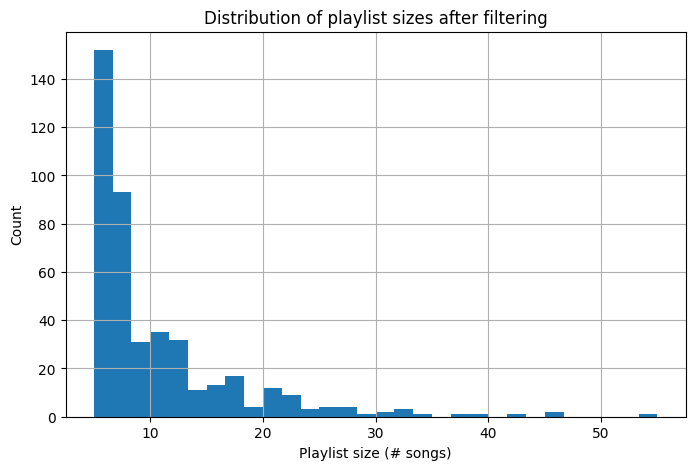

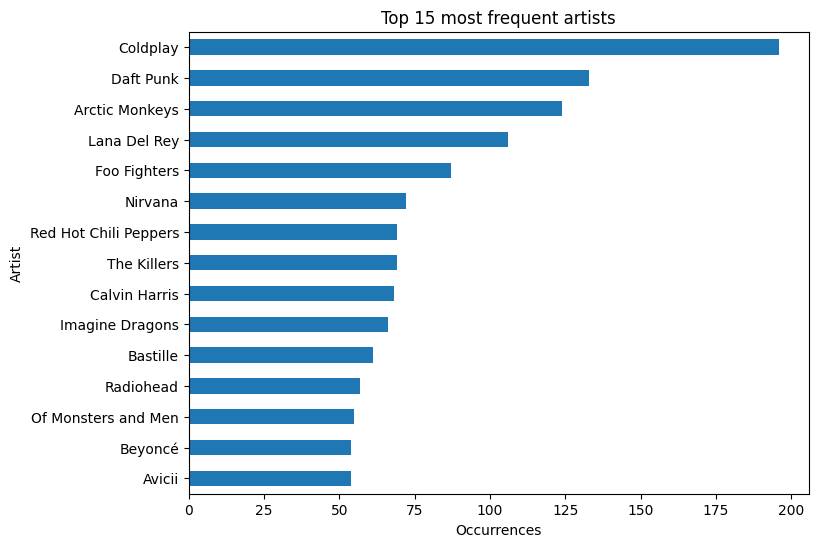

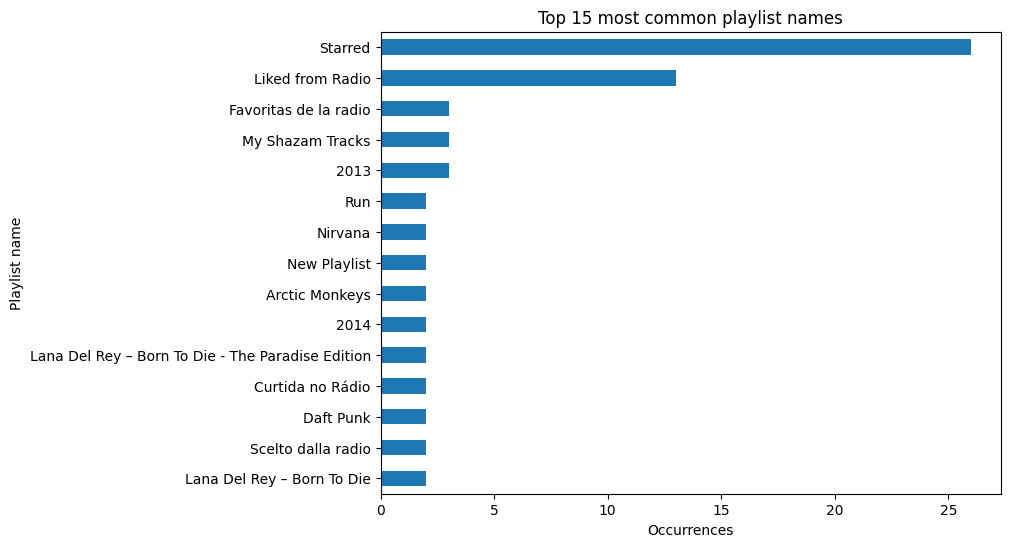


Train playlists: 347
Test playlists: 86
Usable masked test playlists: 86

Evaluation finished in 0.06 seconds

Preliminary recommendation results:


,model,HitRate@10,Recall@10,MRR@10,num_test_cases
0,Popularity Baseline,0.069767,0.038760,0.022979,86
1,Co-occurrence Baseline,0.441860,0.321705,0.269214,86


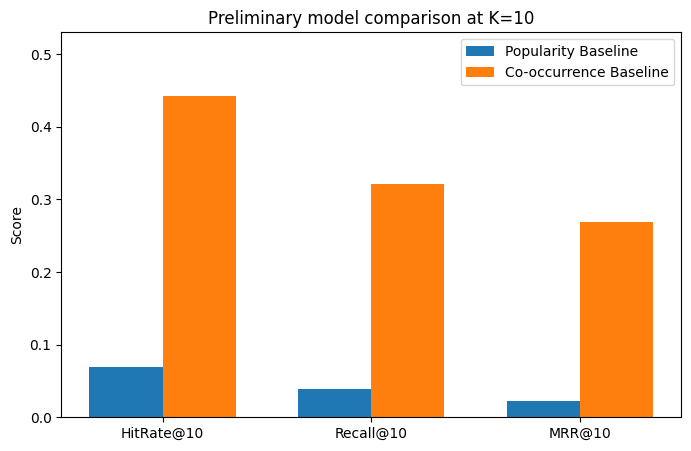


Example recommendations on a few masked test playlists:

Example 1
Observed songs:
  - Robin Thicke — Blurred Lines
  - OneRepublic — Counting Stars
  - Train — Drive By
  - JAY Z — Holy Grail
  - Bruno Mars — Locked Out Of Heaven
  - Beyoncé — Love On Top
  - LMFAO — Party Rock Anthem
  - Katy Perry — Roar
  - ...
Hidden true songs:
  * Beyoncé — Drunk in Love
  * Beyoncé — Countdown
  * OutKast — Hey Ya! - Radio Mix / Club Mix
Popularity recommendations:
  > Bastille — Pompeii
  > M83 — Midnight City
  > Clean Bandit — Rather Be (feat. Jess Glynne)
  > Imagine Dragons — Radioactive
  > Of Monsters and Men — Little Talks
Co-occurrence recommendations:
  > Imagine Dragons — Radioactive
  > Lorde — Royals
  > Bastille — Pompeii
  > Daft Punk — Get Lucky - Radio Edit
  > Drake — Hold On, We're Going Home
------------------------------------------------------------
Example 2
Observed songs:
  - José González — Heartbeats
  - Grimes — Oblivion
  - Vance Joy — Riptide
  - Milky Chance — St

In [1]:
# ============================================================
# CS506 Final Project
# Playlist-based Music Recommendation (Preliminary Pipeline)
# ============================================================

import os
import csv
import re
import math
import time
import random
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# [Stage 1] Reproducibility
# -----------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_PATH = "spotify_dataset.csv"
MIN_PLAYLIST_SIZE = 5
MAX_PLAYLIST_SIZE = 200
MIN_SONG_FREQ = 20
MAX_PLAYLISTS_FOR_MODELING = 50000
TOPK = 10
TEST_FRAC = 0.2

print("=" * 70)
print("Starting pipeline...")
print("=" * 70)

# -----------------------------
# [Stage 2] Loading data and Standardization
# -----------------------------
def clean_col(c: str) -> str:
    c = str(c).strip()
    if c.startswith('"') and c.endswith('"') and len(c) >= 2:
        c = c[1:-1].strip()
    return c

def robust_load_csv(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8", errors="replace", newline="") as f:
        header_line = f.readline().rstrip("\n")
    raw_header = next(csv.reader([header_line], delimiter=",", quotechar='"', escapechar="\\"))
    expected_cols = len(raw_header)
    header = [clean_col(c) for c in raw_header]

    good_rows = []
    bad_count = 0
    with open(path, "r", encoding="utf-8", errors="replace", newline="") as f:
        reader = csv.reader(f, delimiter=",", quotechar='"', escapechar="\\")
        _ = next(reader)
        for row in reader:
            if len(row) == expected_cols:
                good_rows.append(row)
            else:
                bad_count += 1

    out = pd.DataFrame(good_rows, columns=header)
    print(f"Loaded shape: {out.shape}")
    print(f"Bad rows dropped during load: {bad_count}")
    print(f"Columns: {list(out.columns)}")
    return out

if "df" in globals() and isinstance(df, pd.DataFrame):
    print("Using existing df already in memory.")
    work_df = df.copy()
else:
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(
            f"Could not find '{DATA_PATH}'. Either put the CSV in the same folder "
            f"or run your earlier preprocessing cell first so df exists."
        )
    print(f"Loading from file: {DATA_PATH}")
    work_df = robust_load_csv(DATA_PATH)

USER_COL = "user_id"
ARTIST_COL = "artistname"
TRACK_COL = "trackname"
PLAYLIST_COL = "playlistname"

missing = [c for c in [USER_COL, ARTIST_COL, TRACK_COL, PLAYLIST_COL] if c not in work_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nAvailable columns: {list(work_df.columns)}")

def normalize_text(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s)
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower().strip()
    s = s.replace("&", " and ")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

for col in [USER_COL, ARTIST_COL, TRACK_COL, PLAYLIST_COL]:
    work_df[col] = work_df[col].fillna("").astype(str)

if "artist_norm" not in work_df.columns:
    work_df["artist_norm"] = work_df[ARTIST_COL].map(normalize_text)
if "track_norm" not in work_df.columns:
    work_df["track_norm"] = work_df[TRACK_COL].map(normalize_text)

work_df["song_key"] = work_df["artist_norm"] + " — " + work_df["track_norm"]
work_df["playlist_key"] = work_df[USER_COL].astype(str) + " :: " + work_df[PLAYLIST_COL].map(normalize_text)

# remove empty broken records
before = len(work_df)
work_df = work_df[
    (work_df["song_key"].str.strip() != "—") &
    (work_df["artist_norm"].str.strip() != "") &
    (work_df["track_norm"].str.strip() != "") &
    (work_df["playlist_key"].str.strip() != "")
].copy()
print(f"Removed empty/broken rows: {before - len(work_df):,}")

# remove duplicate (playlist, song)
before = len(work_df)
work_df = work_df.drop_duplicates(subset=["playlist_key", "song_key"], keep="first").copy()
print(f"Removed duplicate (playlist, song) rows: {before - len(work_df):,}")
print(f"Shape after cleaning: {work_df.shape}")

# -----------------------------
# [Stage 3] Feature extraction and filtering
# -----------------------------
# song popularity
song_freq = work_df["song_key"].value_counts()
work_df["song_freq"] = work_df["song_key"].map(song_freq)

# playlist size
playlist_size = work_df.groupby("playlist_key")["song_key"].nunique()
work_df["playlist_size"] = work_df["playlist_key"].map(playlist_size)

# artist count per playlist
playlist_artist_count = work_df.groupby("playlist_key")["artist_norm"].nunique()
work_df["playlist_artist_count"] = work_df["playlist_key"].map(playlist_artist_count)

# artist diversity ratio
work_df["artist_diversity_ratio"] = work_df["playlist_artist_count"] / work_df["playlist_size"].clip(lower=1)

# filter playlists and songs for a more stable preliminary model
filtered = work_df[
    (work_df["playlist_size"] >= MIN_PLAYLIST_SIZE) &
    (work_df["playlist_size"] <= MAX_PLAYLIST_SIZE) &
    (work_df["song_freq"] >= MIN_SONG_FREQ)
].copy()

# recompute sizes after filtering
filtered_playlist_size = filtered.groupby("playlist_key")["song_key"].nunique()
filtered = filtered[filtered["playlist_key"].isin(filtered_playlist_size.index)].copy()
filtered["playlist_size_filtered"] = filtered["playlist_key"].map(filtered_playlist_size)

# keep only playlists that still have enough songs after song filtering
filtered = filtered[
    (filtered["playlist_size_filtered"] >= MIN_PLAYLIST_SIZE)
].copy()

print(f"Shape after frequency/size filtering: {filtered.shape}")
print(f"Unique playlists after filtering: {filtered['playlist_key'].nunique():,}")
print(f"Unique songs after filtering: {filtered['song_key'].nunique():,}")
print(f"Unique users after filtering: {filtered[USER_COL].nunique():,}")

# sample playlists if too many for quick modeling
all_playlists = filtered["playlist_key"].drop_duplicates().tolist()
if len(all_playlists) > MAX_PLAYLISTS_FOR_MODELING:
    sampled_playlists = set(random.sample(all_playlists, MAX_PLAYLISTS_FOR_MODELING))
    filtered = filtered[filtered["playlist_key"].isin(sampled_playlists)].copy()
    print(f"Subsampled to {MAX_PLAYLISTS_FOR_MODELING:,} playlists for faster modeling.")
else:
    print("Using all filtered playlists for modeling.")

# recompute final playlist sizes after sampling
final_playlist_size = filtered.groupby("playlist_key")["song_key"].nunique()
filtered["playlist_size_final"] = filtered["playlist_key"].map(final_playlist_size)

# map song key to readable display name
song_display_map = (
    filtered.groupby("song_key")[[ARTIST_COL, TRACK_COL]]
    .first()
    .assign(display_name=lambda x: x[ARTIST_COL].astype(str) + " — " + x[TRACK_COL].astype(str))
)["display_name"].to_dict()

# playlist summary features
playlist_features = (
    filtered.groupby("playlist_key")
    .agg(
        user_id=(USER_COL, "first"),
        playlist_name=(PLAYLIST_COL, "first"),
        n_songs=("song_key", "nunique"),
        n_artists=("artist_norm", "nunique"),
        avg_song_popularity=("song_freq", "mean")
    )
    .reset_index()
)
playlist_features["artist_diversity_ratio"] = playlist_features["n_artists"] / playlist_features["n_songs"].clip(lower=1)

print("\nPlaylist-level feature preview:")
display(playlist_features.head())

# -----------------------------
# [Stage 4] Visualizations
# -----------------------------
plt.figure(figsize=(8, 5))
playlist_features["n_songs"].hist(bins=30)
plt.xlabel("Playlist size (# songs)")
plt.ylabel("Count")
plt.title("Distribution of playlist sizes after filtering")
plt.show()

top_artists = filtered["artistname"].value_counts().head(15).sort_values()
plt.figure(figsize=(8, 6))
top_artists.plot(kind="barh")
plt.xlabel("Occurrences")
plt.ylabel("Artist")
plt.title("Top 15 most frequent artists")
plt.show()

top_playlist_names = playlist_features["playlist_name"].value_counts().head(15).sort_values()
plt.figure(figsize=(8, 6))
top_playlist_names.plot(kind="barh")
plt.xlabel("Occurrences")
plt.ylabel("Playlist name")
plt.title("Top 15 most common playlist names")
plt.show()

# -----------------------------
# [Stage 5] Build playlist -> songs data
# -----------------------------
playlist_to_songs = filtered.groupby("playlist_key")["song_key"].apply(list).to_dict()

# ensure unique within playlist and stable order
for pk in list(playlist_to_songs.keys()):
    seen = set()
    deduped = []
    for s in playlist_to_songs[pk]:
        if s not in seen:
            deduped.append(s)
            seen.add(s)
    playlist_to_songs[pk] = deduped

all_playlist_keys = list(playlist_to_songs.keys())
random.shuffle(all_playlist_keys)

n_test = max(1, int(len(all_playlist_keys) * TEST_FRAC))
test_playlists = set(all_playlist_keys[:n_test])
train_playlists = set(all_playlist_keys[n_test:])

train_playlist_to_songs = {k: playlist_to_songs[k] for k in train_playlists}
test_playlist_to_songs = {k: playlist_to_songs[k] for k in test_playlists}

print(f"\nTrain playlists: {len(train_playlist_to_songs):,}")
print(f"Test playlists: {len(test_playlist_to_songs):,}")

# -----------------------------
# [Stage 6] Create masked test cases
# -----------------------------
def make_test_cases(test_dict, min_input_size=2, max_hide=3):
    cases = []
    for pk, songs in test_dict.items():
        if len(songs) < (min_input_size + 1):
            continue
        n_hide = max(1, min(max_hide, int(round(0.2 * len(songs)))))
        if len(songs) - n_hide < min_input_size:
            n_hide = len(songs) - min_input_size
        if n_hide <= 0:
            continue

        hidden = set(random.sample(songs, n_hide))
        observed = [s for s in songs if s not in hidden]

        if len(observed) < min_input_size or len(hidden) == 0:
            continue

        cases.append({
            "playlist_key": pk,
            "observed": observed,
            "hidden": hidden
        })
    return cases

test_cases = make_test_cases(test_playlist_to_songs)
print(f"Usable masked test playlists: {len(test_cases):,}")

# -----------------------------
# [Stage 7] Popularity baseline
# -----------------------------
train_song_popularity = Counter()
for songs in train_playlist_to_songs.values():
    train_song_popularity.update(songs)

popular_ranking = [song for song, _ in train_song_popularity.most_common()]

def recommend_popularity(observed_songs, topk=10):
    seen = set(observed_songs)
    recs = []
    for s in popular_ranking:
        if s not in seen:
            recs.append(s)
        if len(recs) >= topk:
            break
    return recs

# -----------------------------
# [Stage 8] Item-item co-occurrence model
# -----------------------------
song_to_playlists = defaultdict(set)
for pk, songs in train_playlist_to_songs.items():
    for s in songs:
        song_to_playlists[s].add(pk)

playlist_song_set = {pk: set(songs) for pk, songs in train_playlist_to_songs.items()}

def recommend_cooccurrence(observed_songs, topk=10):
    observed = set(observed_songs)
    candidate_scores = defaultdict(float)

    for s in observed:
        playlists_with_s = song_to_playlists.get(s, set())
        if not playlists_with_s:
            continue

        for pk in playlists_with_s:
            for candidate in playlist_song_set[pk]:
                if candidate in observed:
                    continue
                candidate_scores[candidate] += 1.0

    if not candidate_scores:
        return recommend_popularity(observed_songs, topk=topk)

    ranked = sorted(candidate_scores.items(), key=lambda x: (-x[1], -train_song_popularity[x[0]], x[0]))
    recs = [song for song, score in ranked[:topk]]

    # backfill with popularity if fewer than topk
    if len(recs) < topk:
        seen = observed.union(recs)
        for s in popular_ranking:
            if s not in seen:
                recs.append(s)
            if len(recs) >= topk:
                break

    return recs[:topk]

# -----------------------------
# [Stage 9] Evaluation
# -----------------------------
def evaluate_model(test_cases, recommender_fn, topk=10):
    hits = []
    recalls = []
    reciprocal_ranks = []

    for case in test_cases:
        observed = case["observed"]
        hidden = case["hidden"]
        recs = recommender_fn(observed, topk=topk)

        rec_set = set(recs)
        n_hit = len(hidden.intersection(rec_set))

        hit = 1.0 if n_hit > 0 else 0.0
        recall = n_hit / len(hidden)

        rr = 0.0
        for rank, item in enumerate(recs, start=1):
            if item in hidden:
                rr = 1.0 / rank
                break

        hits.append(hit)
        recalls.append(recall)
        reciprocal_ranks.append(rr)

    return {
        f"HitRate@{topk}": float(np.mean(hits)) if hits else 0.0,
        f"Recall@{topk}": float(np.mean(recalls)) if recalls else 0.0,
        f"MRR@{topk}": float(np.mean(reciprocal_ranks)) if reciprocal_ranks else 0.0,
        "num_test_cases": len(test_cases)
    }

start_eval = time.time()
pop_metrics = evaluate_model(test_cases, recommend_popularity, topk=TOPK)
co_metrics  = evaluate_model(test_cases, recommend_cooccurrence, topk=TOPK)
print(f"\nEvaluation finished in {time.time() - start_eval:.2f} seconds")

results_df = pd.DataFrame([
    {"model": "Popularity Baseline", **pop_metrics},
    {"model": "Co-occurrence Baseline", **co_metrics}
])

print("\nPreliminary recommendation results:")
display(results_df)

# -----------------------------
# [Stage 10] Plot metric comparison
# -----------------------------
metric_cols = [f"HitRate@{TOPK}", f"Recall@{TOPK}", f"MRR@{TOPK}"]
plot_df = results_df.set_index("model")[metric_cols]

plt.figure(figsize=(8, 5))
x = np.arange(len(metric_cols))
width = 0.35

models = plot_df.index.tolist()
vals1 = plot_df.iloc[0].values
vals2 = plot_df.iloc[1].values if len(plot_df) > 1 else np.zeros_like(vals1)

plt.bar(x - width/2, vals1, width, label=models[0])
if len(plot_df) > 1:
    plt.bar(x + width/2, vals2, width, label=models[1])

plt.xticks(x, metric_cols)
plt.ylabel("Score")
plt.title(f"Preliminary model comparison at K={TOPK}")
plt.ylim(0, max(0.05, plot_df.max().max() * 1.2))
plt.legend()
plt.show()

# -----------------------------
# [Stage 11] Example recommendations
# -----------------------------
def pretty_song(song_key):
    return song_display_map.get(song_key, song_key)

print("\nExample recommendations on a few masked test playlists:\n")
for i, case in enumerate(test_cases[:5], start=1):
    observed = case["observed"]
    hidden = case["hidden"]

    pop_recs = recommend_popularity(observed, topk=TOPK)
    co_recs = recommend_cooccurrence(observed, topk=TOPK)

    print(f"Example {i}")
    print("Observed songs:")
    for s in observed[:8]:
        print("  -", pretty_song(s))
    if len(observed) > 8:
        print("  - ...")

    print("Hidden true songs:")
    for s in hidden:
        print("  *", pretty_song(s))

    print("Popularity recommendations:")
    for s in pop_recs[:5]:
        print("  >", pretty_song(s))

    print("Co-occurrence recommendations:")
    for s in co_recs[:5]:
        print("  >", pretty_song(s))
    print("-" * 60)

# -----------------------------
# [Stage 12] Process Summary
# -----------------------------
print("\n" + "=" * 70)
print("CHECK-IN SUMMARY")
print("=" * 70)
print(f"Rows after cleaning/filtering: {len(filtered):,}")
print(f"Playlists used for modeling: {filtered['playlist_key'].nunique():,}")
print(f"Songs used for modeling: {filtered['song_key'].nunique():,}")
print(f"Users represented: {filtered[USER_COL].nunique():,}")
print()
print("Features extracted so far:")
print("1. song_freq                -> track popularity")
print("2. playlist_size            -> number of songs in a playlist")
print("3. playlist_artist_count    -> number of distinct artists")
print("4. artist_diversity_ratio   -> artist diversity inside playlist")
print()
print("Models tested so far:")
print("1. Popularity baseline")
print("2. Item-item co-occurrence baseline")
print()
print("Interpretation:")
if co_metrics[f"Recall@{TOPK}"] >= pop_metrics[f"Recall@{TOPK}"]:
    print("The co-occurrence model outperforms or matches the popularity baseline,")
    print("which suggests playlist context contains useful signal beyond global popularity.")
else:
    print("The popularity baseline is currently competitive or stronger,")
    print("which suggests we may need better filtering, richer features, or stronger models.")
print()
print("=" * 70)